# FGW vs Relaxed Energy (3-panel hexbin, square main axes)
Publication-style 3-panel figure with square main axes, true hexbin panels, top/right marginal histograms, no fitting line, and correlation labels.

Saved: fgw_relaxed_hexbin_3panel_nofit_v6.pdf


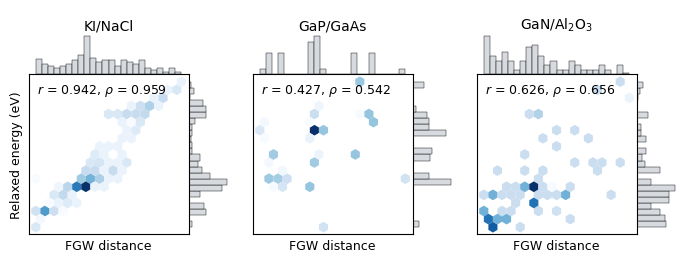

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ---- Input ----
csv_paths = [
    "../mace_results/KI_NaCl_opt.csv",
    "../mace_results/GaP_GaAs_opt.csv",
    "../mace_results/GaN_Al2O3_opt.csv",
]

titles = ["KI/NaCl", "GaP/GaAs", "GaN/Al$_2$O$_3$"]

# ---- Style ----
SCATTER_CMAP = "Blues"
HIST_COLOR = "#D3D8DC"
HIST_EDGE = "#000000"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig = plt.figure(figsize=(7.2, 3.35), constrained_layout=False)
outer = fig.add_gridspec(
    1, 3,
    left=0.05, right=0.95, bottom=0.05, top=0.95,
    wspace=0.12
)

HIST_RATIO = 0.25

for i, (path, title) in enumerate(zip(csv_paths, titles)):
    df = pd.read_csv(path).copy()

    x = pd.to_numeric(df["fgw_distance"], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df["relaxed_energy"], errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2 or np.allclose(np.std(x), 0.0) or np.allclose(np.std(y), 0.0):
        r = np.nan
        rho = np.nan
    else:
        r = float(pearsonr(x, y).statistic)
        rho = float(spearmanr(x, y).statistic)

    # Temporary axes from GridSpec; final positions are set manually after draw
    inner = outer[i].subgridspec(
        3, 2,
        height_ratios=[0.45, 1.0, 4.0],
        width_ratios=[4.0, 1.0],
        hspace=0.0,
        wspace=0.0
    )

    ax_title = fig.add_subplot(inner[0, 0])
    ax_histx = fig.add_subplot(inner[1, 0])
    ax = fig.add_subplot(inner[2, 0], sharex=ax_histx)
    ax_histy = fig.add_subplot(inner[2, 1], sharey=ax)

    # Draw histogram axes behind the main axis
    ax_histx.set_zorder(0)
    ax_histy.set_zorder(0)
    ax.set_zorder(2)

    ax_histx.patch.set_alpha(0.0)
    ax_histy.patch.set_alpha(0.0)

    # Main panel square
    ax.set_box_aspect(1)

    # Main hexbin
    ax.hexbin(
        x, y,
        gridsize=16,
        cmap=SCATTER_CMAP,
        mincnt=1,
        linewidths=0.0
    )

    label = (
        rf"$r$ = {r:.3f}, $\rho$ = {rho:.3f}"
        if np.isfinite(r) and np.isfinite(rho)
        else r"$r$ = –, $\rho$ = –"
    )
    ax.text(
        0.05, 0.95, label,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9
    )

    # Marginal histograms
    ax_histx.hist(
        x,
        bins=24,
        color=HIST_COLOR,
        edgecolor=HIST_EDGE,
        linewidth=0.35,
        alpha=0.9
    )
    ax_histy.hist(
        y,
        bins=24,
        orientation="horizontal",
        color=HIST_COLOR,
        edgecolor=HIST_EDGE,
        linewidth=0.35,
        alpha=0.9
    )

    # Clean histogram axes
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])
    ax_histy.set_xticks([])
    ax_histy.set_yticks([])

    for spine in ax_histx.spines.values():
        spine.set_visible(False)
    for spine in ax_histy.spines.values():
        spine.set_visible(False)

    # Main axis style
    ax.tick_params(direction="out", length=3, width=1, top=False, right=False)
    ax.set_xlabel("FGW distance", fontsize=9)

    if i == 0:
        ax.set_ylabel("Relaxed energy (eV)", fontsize=9)
    else:
        ax.set_yticklabels([])

    # First draw so square box_aspect takes effect
    fig.canvas.draw()
    main_pos = ax.get_position()
    title_pos = ax_title.get_position()

    # Force histogram ranges to match the scatter axis
    ax_histx.set_xlim(ax.get_xlim())
    ax_histy.set_ylim(ax.get_ylim())

    # Reposition histograms to be exactly flush and equal in length/height
    ax_histx.set_position([
        main_pos.x0,
        main_pos.y1,
        main_pos.width,
        main_pos.height * HIST_RATIO
    ])

    ax_histy.set_position([
        main_pos.x1,
        main_pos.y0,
        main_pos.width * HIST_RATIO,
        main_pos.height
    ])

    # Title row spans the same width as the main axis and sits above the top histogram
    title_height = title_pos.height
    ax_title.set_position([
        main_pos.x0,
        main_pos.y1 + main_pos.height * HIST_RATIO,
        main_pos.width,
        title_height
    ])
    ax_title.axis("off")
    ax_title.text(0.5, 0.05, title, ha="center", va="bottom", fontsize=10)

output = "fgw_relaxed_hexbin_3panel_nofit_v6.pdf"
plt.savefig(output, bbox_inches="tight")
print("Saved:", output)

plt.show()
